<a href="https://colab.research.google.com/github/mbabar1100/BreastCancerDetectionUsingRandomForest/blob/main/BreastCancerDetectionUsingRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title: Breast Cancer Detection and Exploratory Data Analysis using Random Forest**
This project focuses on building a predictive model for breast cancer detection using the Random Forest Classifier. The dataset is analyzed through a comprehensive Exploratory Data Analysis (EDA) process to uncover patterns, relationships, and anomalies within the data. Key steps include class distribution analysis, visualization of feature distributions, correlation heatmaps, outlier detection, and dimensionality reduction using PCA. After preprocessing, a Random Forest model is trained and evaluated to classify whether a tumor is malignant or benign. This workflow demonstrates how machine learning and statistical analysis can be combined to support early diagnosis in healthcare.

Step 1: Import Libraries python

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


Step 2: Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving breast_cancer_dataset.csv to breast_cancer_dataset.csv


Step 3: Understand the Data

In [ ]:
# Get summary of the dataset
df.info()

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       5015 non-null   int64  
 1   diagnosis                5015 non-null   int64  
 2   radius_mean              5015 non-null   float64
 3   texture_mean             5015 non-null   float64
 4   perimeter_mean           5015 non-null   float64
 5   area_mean                5015 non-null   float64
 6   smoothness_mean          5015 non-null   float64
 7   compactness_mean         5015 non-null   float64
 8   concavity_mean           5015 non-null   float64
 9   concave points_mean      5015 non-null   float64
 10  symmetry_mean            5015 non-null   float64
 11  fractal_dimension_mean   5015 non-null   float64
 12  radius_se                5015 non-null   float64
 13  texture_se               5015 non-null   float64
 14  perimeter_se            

Step 4: Display first few rows

In [ ]:
# Load the uploaded file — make sure the name matches exactly
df = pd.read_csv('breast_cancer_dataset.csv')

# Display the first few rows
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,M,0.425053,5.965067,1.878999,-1.922577,-8.191107,-9.662919,-0.619291,-1.315248,...,0.615896,2.002757,-0.201908,0.120528,0.035929,-0.582654,10.078263,3.396570,-0.474207,0.938795
1,2,B,-0.720491,1.122032,0.702666,0.588757,-2.897603,6.737809,0.293614,-2.898675,...,-1.545681,0.131865,-1.040233,-0.323723,1.218420,0.165080,0.415971,-2.714283,2.652932,-0.403200
2,3,B,1.624526,0.466168,1.600550,2.200664,4.272945,2.390065,0.614031,-0.314448,...,-0.118669,-1.379621,-1.324658,-0.282837,5.802867,-0.325060,-4.156908,1.968221,-0.054791,0.076663
3,4,M,-1.124956,-2.165492,-0.215090,-1.795210,-6.011122,-7.283305,0.147977,-1.520045,...,1.001215,0.350980,-0.173384,1.782559,-2.723687,-6.602257,-8.789461,5.394188,0.201087,-0.310054
4,5,B,-0.349488,-1.915211,-2.885086,-0.182034,1.586092,1.645780,-0.532385,-1.009785,...,-0.538012,1.444644,0.758448,-0.303827,4.672285,-5.195357,-3.044978,1.988163,-0.465882,-0.207049


Step 5: Encode Categorical Columns (if any)

In [ ]:
# Automatically encode object (string) columns to numeric
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])


Step 6: Identify and Split Features & Target

In [ ]:
# Show available columns and unique values in the target
print("Columns:", df.columns.tolist())
print("Unique values in the last column:", df.iloc[:, -1].unique())

# Use all columns except the last one as features, and the last column as target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert continuous target to binary class if needed
if y.dtype in ['float64', 'int64'] and len(y.unique()) > 10:
    y = (y > y.median()).astype(int)


Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Unique values in the last column: [ 0.93879527 -0.40320001  0.07666309 ... -0.52465903  1.25567786
  0.45902397]


Step 7: Split into Train and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step 8: Train the Random Forest Classifier

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Step 9: Make Predictions and Evaluate

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.4885343968095713

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.53      0.51       496
           1       0.49      0.45      0.47       507

    accuracy                           0.49      1003
   macro avg       0.49      0.49      0.49      1003
weighted avg       0.49      0.49      0.49      1003

Confusion Matrix:
 [[263 233]
 [280 227]]


Step 9: Plot Feature Importances

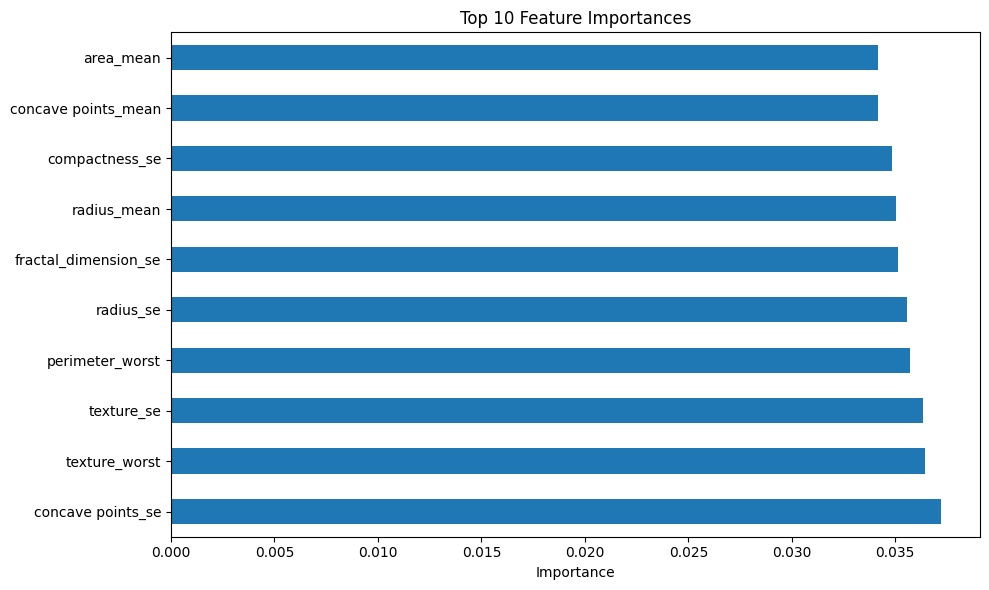

In [ ]:
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Step 10: Exploratory data analysis

Shape of dataset: (5015, 32)

Data Types:
 id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_

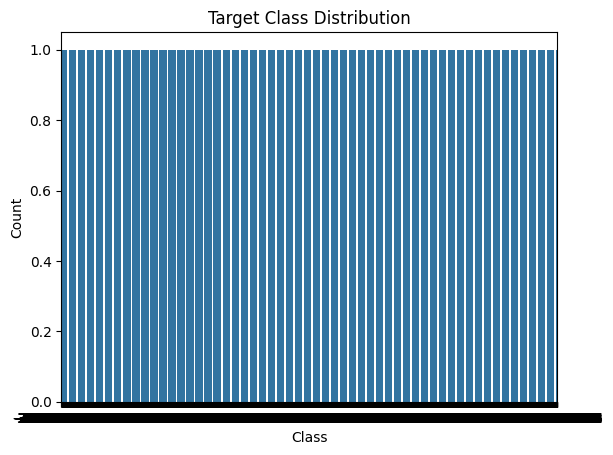

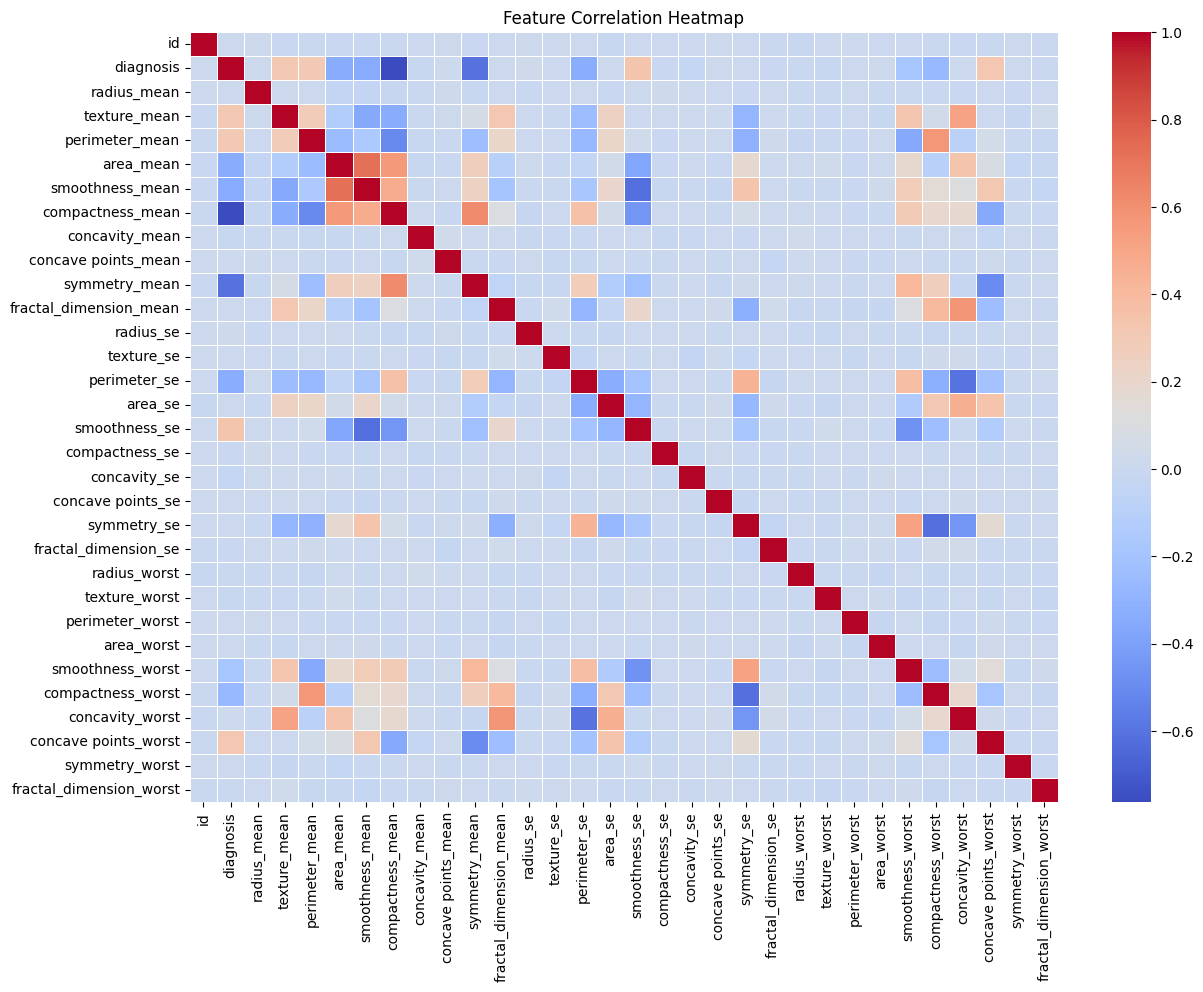

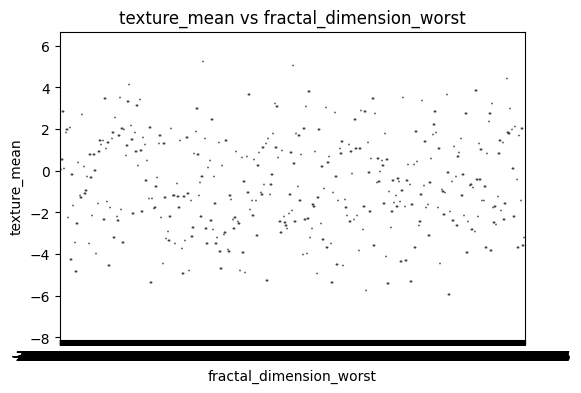

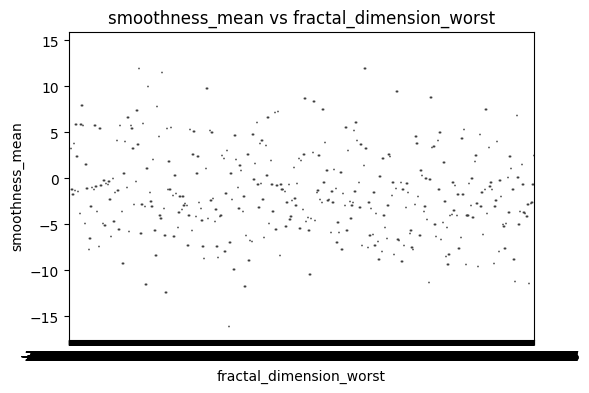

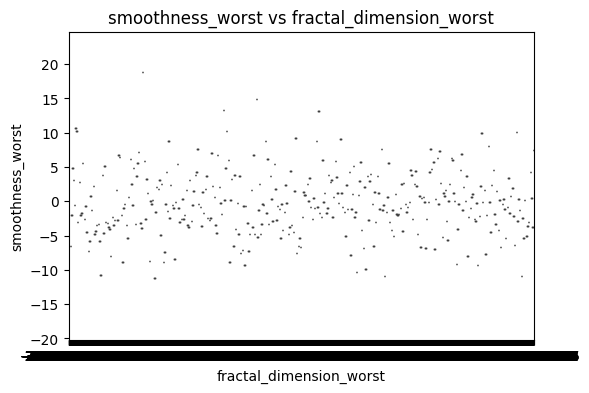

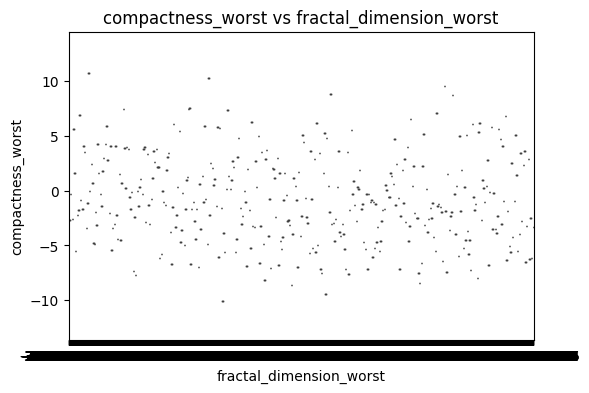

In [ ]:
# Dataset shape and preview
print("Shape of dataset:", df.shape)
df.head()


# Check datatypes and missing values
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


# Summary statistics
df.describe()


# If your target is in the last column
target_col = df.columns[-1]

# Plot distribution of target
sns.countplot(x=df[target_col])
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()



# Compute correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


# Only run this if you have fewer columns, else it will be slow
if df.shape[1] <= 10:
    sns.pairplot(df, hue=target_col)
    plt.show()



# Plot boxplots for top 4 numeric features by correlation with target
top_features = corr[target_col].abs().sort_values(ascending=False)[1:5].index

for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} vs {target_col}")
    plt.show()



🔍 Class Distribution:
fractal_dimension_worst
 0.459024    0.000199
 0.938795    0.000199
-0.403200    0.000199
 0.076663    0.000199
-0.310054    0.000199
               ...   
 0.064067    0.000199
-1.177050    0.000199
 0.005183    0.000199
 1.083063    0.000199
 0.989567    0.000199
Name: proportion, Length: 5015, dtype: float64

📊 Plotting histograms...


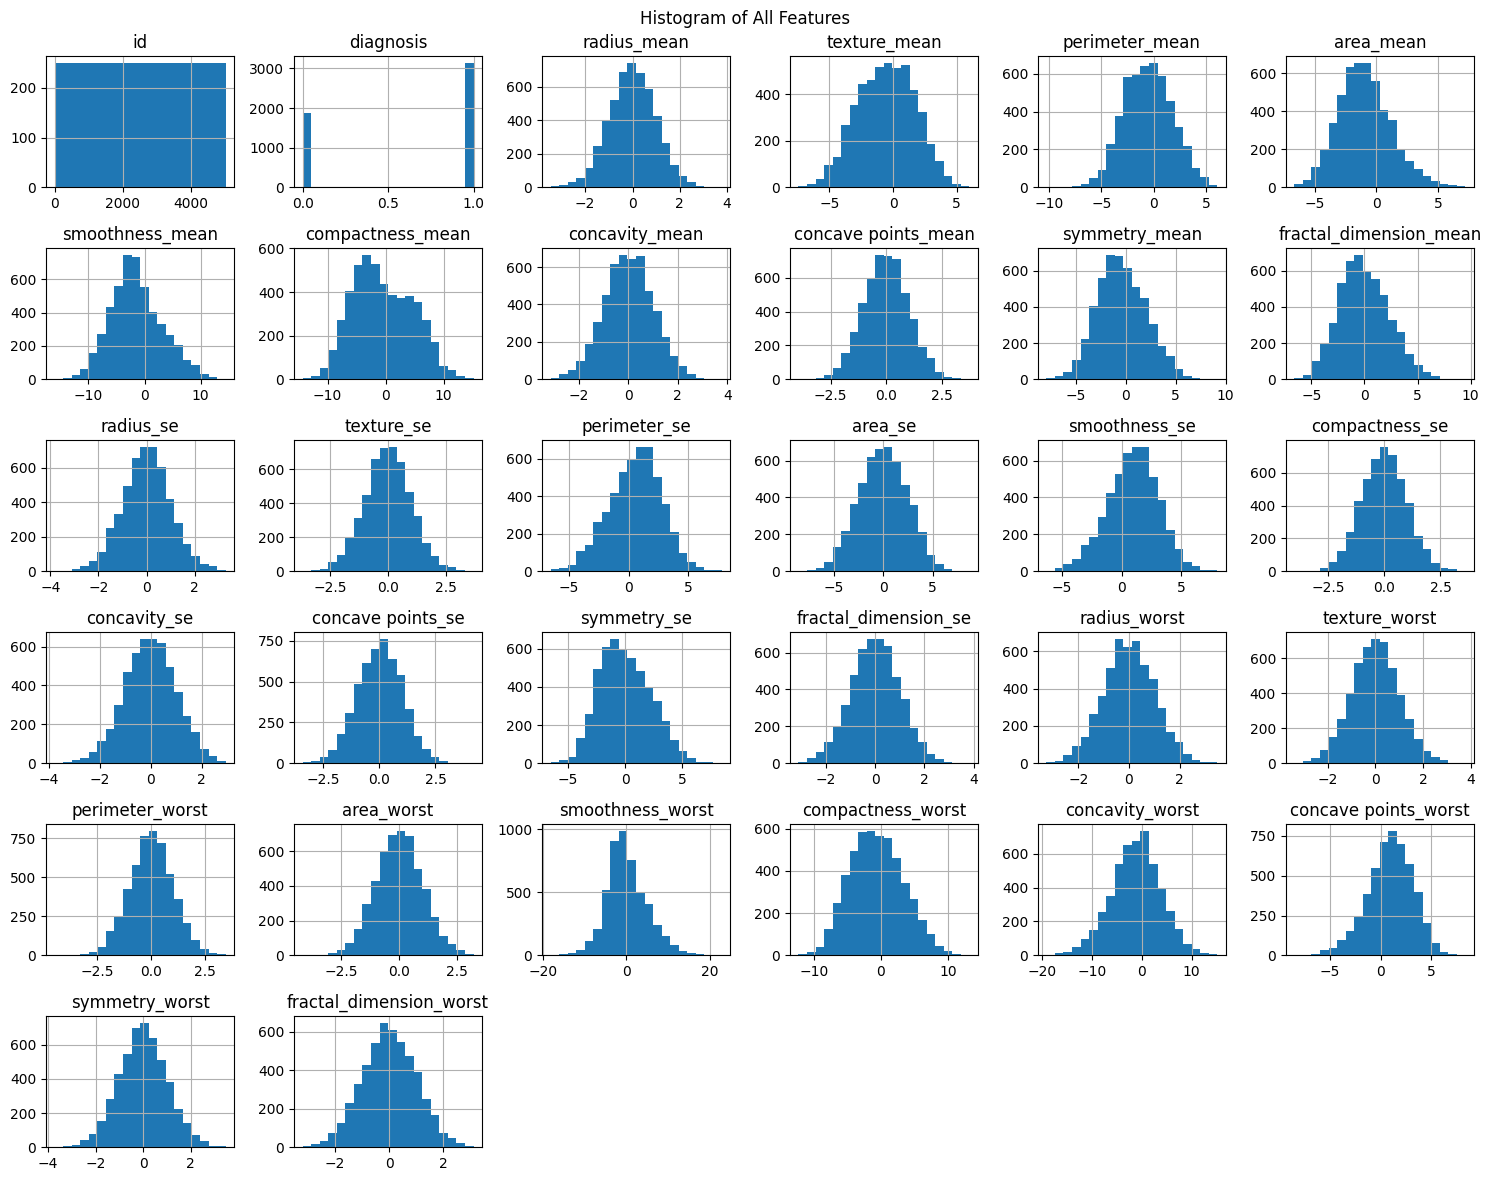


📈 KDE Plots (by class) for first 5 usable numeric columns:
⚠️ Skipping diagnosis (no variance across classes)
⚠️ Skipping radius_mean (no variance across classes)
⚠️ Skipping texture_mean (no variance across classes)
⚠️ Skipping perimeter_mean (no variance across classes)
⚠️ Skipping area_mean (no variance across classes)

🚨 Outlier Count (Z-score > 3):
id                          0
diagnosis                   0
radius_mean                23
texture_mean                2
perimeter_mean              4
area_mean                  19
smoothness_mean             8
compactness_mean            2
concavity_mean             10
concave points_mean        19
symmetry_mean               8
fractal_dimension_mean      5
radius_se                  13
texture_se                 15
perimeter_se               10
area_se                     6
smoothness_se              12
compactness_se             14
concavity_se               13
concave points_se          12
symmetry_se                11
fractal_dimen

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

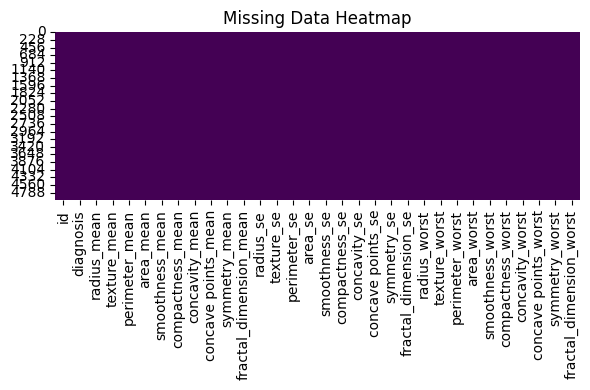


📌 Correlation with Target:
Top positively correlated features:
 fractal_dimension_worst    1.000000
texture_mean               0.035608
smoothness_worst           0.024873
concave points_se          0.019169
radius_se                  0.016375
Name: fractal_dimension_worst, dtype: float64
Top negatively correlated features:
 perimeter_mean      -0.015574
area_mean           -0.016883
texture_worst       -0.022812
compactness_worst   -0.024798
smoothness_mean     -0.029966
Name: fractal_dimension_worst, dtype: float64

🧬 PCA Visualization (2D):


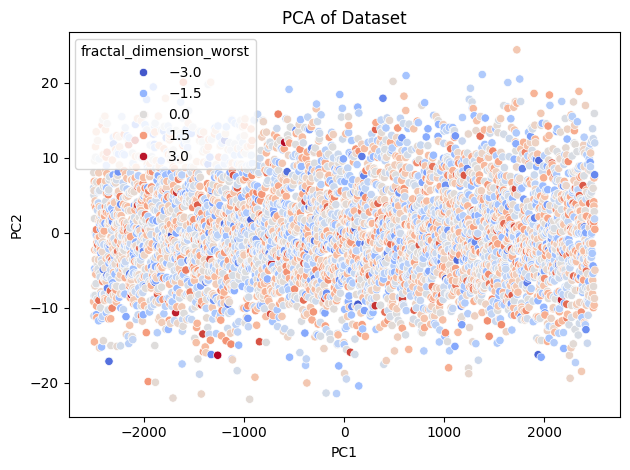


🧠 Clustermap of Feature Correlations:


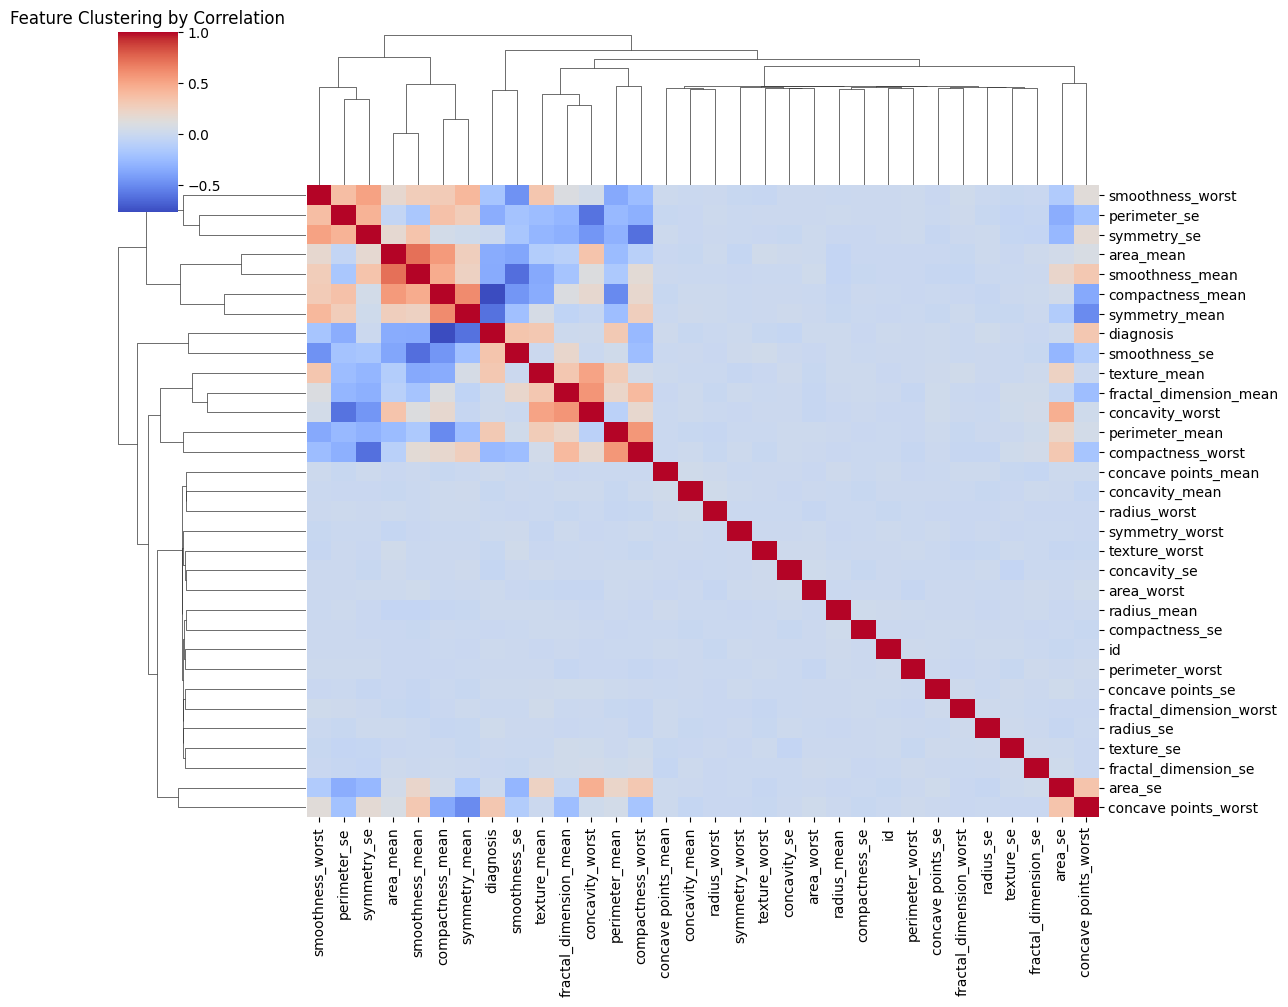


📏 Skewness and Kurtosis of Numeric Features:
                          Skew  Kurtosis
diagnosis            -0.529437 -1.720383
smoothness_worst      0.373174  0.739404
area_mean             0.371253  0.192113
concave points_worst -0.361561  0.232061
smoothness_mean       0.336067 -0.064634


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA

# 1. Class Imbalance Check
print("\n🔍 Class Distribution:")
print(df[target_col].value_counts(normalize=True))

# 2. Distribution Analysis – Histograms
print("\n📊 Plotting histograms...")
df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Histogram of All Features")
plt.tight_layout()
plt.show()

# 3. Distribution Analysis – KDE Plots by Class
print("\n📈 KDE Plots (by class) for first 5 usable numeric columns:")

# Select usable numeric columns (excluding 'id' or constant columns)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
usable_cols = [col for col in numeric_cols if col != 'id' and df[col].nunique() > 1]

# Plot first 5
for col in usable_cols[:5]:
    plt.figure(figsize=(6, 4))
    plotted = False
    for label in df[target_col].unique():
        subset = df[df[target_col] == label][col]
        if subset.nunique() > 1:
            sns.kdeplot(subset, label=f"{target_col} = {label}")
            plotted = True
    if plotted:
        plt.title(f"KDE of {col} by {target_col}")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Skipping {col} (no variance across classes)")

# 4. Outlier Detection
print("\n🚨 Outlier Count (Z-score > 3):")
z_scores = np.abs(zscore(df.select_dtypes(include='number')))
outliers = (z_scores > 3).sum(axis=0)
print(outliers)

# 5. Missing Value Heatmap
print("\n🧼 Missing Values Heatmap:")
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.tight_layout()
plt.show()

# 6. Correlation with Target
print("\n📌 Correlation with Target:")
correlation_with_target = df.corr()[target_col].sort_values(ascending=False)
print("Top positively correlated features:\n", correlation_with_target.head())
print("Top negatively correlated features:\n", correlation_with_target.tail())

# 7. PCA Visualization
print("\n🧬 PCA Visualization (2D):")
pca = PCA(n_components=2)
components = pca.fit_transform(df.drop(columns=[target_col]))
df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca[target_col] = df[target_col].values

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=target_col, palette='coolwarm')
plt.title("PCA of Dataset")
plt.tight_layout()
plt.show()

# 8. Feature-Feature Correlation Clustermap
print("\n🧠 Clustermap of Feature Correlations:")
sns.clustermap(df.corr(), cmap="coolwarm", figsize=(12, 10))
plt.title("Feature Clustering by Correlation")
plt.show()

# 9. Skewness & Kurtosis
print("\n📏 Skewness and Kurtosis of Numeric Features:")
skew_kurt = df.skew(numeric_only=True).to_frame('Skew').join(
    df.kurt(numeric_only=True).to_frame('Kurtosis')
)
print(skew_kurt.sort_values(by='Skew', key=abs, ascending=False).head())
